# 👗 Fashion Classifier Fine-Tuning
**EfficientNet-B0 → 15-class clothing classifier**

Uses the `fashion_dataset` already in your Google Drive.

| Step | Time |
|------|------|
| Setup + Mount | ~1 min |
| Training (10 epochs) | ~15 min |
| Evaluation + Export | ~2 min |
| **Total** | **~18 min** |

## 1. Setup & Mount Drive

In [1]:
!pip install -q timm

from google.colab import drive
drive.mount('/content/drive')

import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


## 2. Configuration

In [2]:
# ── Paths ──
DATASET_PATH = '/content/drive/MyDrive/fashion_dataset'
OUTPUT_DIR   = '/content/drive/MyDrive/fashion_weights'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Categories (must match your app) ──
CATEGORIES = [
    'shirt', 't-shirt', 'jacket', 'coat', 'sweater',
    'hoodie', 'jeans', 'pants', 'shorts', 'dress',
    'skirt', 'blouse', 'suit', 'tank_top', 'other',
]
NUM_CLASSES = len(CATEGORIES)

# ── Hyperparameters ──
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 3e-4
WEIGHT_DECAY = 1e-4

# ── Verify dataset ──
for split in ['train', 'val']:
    path = os.path.join(DATASET_PATH, split)
    if os.path.exists(path):
        cats = sorted(os.listdir(path))
        total = sum(len(os.listdir(os.path.join(path, c))) for c in cats)
        print(f'{split}: {total} images across {len(cats)} categories')
        print(f'  Categories: {cats}')
    else:
        print(f'ERROR: {path} not found!')

train: 7500 images across 15 categories
  Categories: ['blouse', 'coat', 'dress', 'hoodie', 'jacket', 'jeans', 'other', 'pants', 'shirt', 'shorts', 'skirt', 'suit', 'sweater', 't-shirt', 'tank_top']
val: 4300 images across 15 categories
  Categories: ['blouse', 'coat', 'dress', 'hoodie', 'jacket', 'jeans', 'other', 'pants', 'shirt', 'shorts', 'skirt', 'suit', 'sweater', 't-shirt', 'tank_top']


## 3. Dataset & DataLoaders

In [8]:
class FashionDataset(Dataset):
    def __init__(self, root, split, categories, transform=None):
        self.samples = []
        self.labels = []
        self.transform = transform
        self.cat_to_idx = {c: i for i, c in enumerate(categories)}

        split_dir = os.path.join(root, split)
        for cat in sorted(os.listdir(split_dir)):
            cat_dir = os.path.join(split_dir, cat)
            if not os.path.isdir(cat_dir):
                continue
            idx = self.cat_to_idx.get(cat)
            if idx is None:
                print(f'  Skipping unknown category: {cat}')
                continue
            for fname in os.listdir(cat_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    self.samples.append(os.path.join(cat_dir, fname))
                    self.labels.append(idx)

        print(f'  Loaded {split}: {len(self.samples)} images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ── Transforms ──
# ── Lighter, faster transforms ──
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = FashionDataset(DATASET_PATH, 'train', CATEGORIES, train_transform)
val_ds   = FashionDataset(DATASET_PATH, 'val',   CATEGORIES, val_transform)

BATCH_SIZE = 64  # bigger batch = fewer steps

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train: {len(train_ds)} images, {len(train_loader)} batches')
print(f'Val:   {len(val_ds)} images, {len(val_loader)} batches')


  Loaded train: 7500 images
  Loaded val: 4300 images
Train: 7500 images, 117 batches
Val:   4300 images, 68 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. Model Setup

In [9]:
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable:,}')

Total params:     4,026,763
Trainable params: 4,026,763


## 5. Training Loop

In [15]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_state = None
start_time = time.time()

CHECKPOINT_EVERY = 2  # save every N epochs
CHECKPOINT_DIR = '/content/drive/MyDrive/fashion_weights/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f'\n--- Epoch {epoch+1}/{EPOCHS} ---')

    # ── Train ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    c=0
    for imgs, labels in train_loader:

        imgs   = imgs.to(device)
        labels = torch.tensor(labels, dtype=torch.long, device=device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        if c%10==0:
          print(c,running_loss)
        c+=1

        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validate ──
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    c=0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(device)
            labels = torch.tensor(labels, dtype=torch.long, device=device)
            logits = model(imgs)
            loss = criterion(logits, labels)

            running_loss += loss.item() * imgs.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += imgs.size(0)
            if c%10==0:
              print(c,running_loss)
            c+=1

    val_loss = running_loss / total
    val_acc  = correct / total

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    # ── Log ──
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(lr)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, f'{CHECKPOINT_DIR}/best.pth')
        marker = ' ** BEST (saved)'

    # ── Periodic checkpoint ──
    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'best_val_acc': best_val_acc,
            'history': history,
        }, f'{CHECKPOINT_DIR}/checkpoint_epoch_{epoch+1}.pth')
        marker += f' [checkpoint saved]'

    elapsed = time.time() - epoch_start
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f} | '
          f'LR: {lr:.6f} | {elapsed:.0f}s{marker}')

total_time = time.time() - start_time
print(f'\nTraining complete in {total_time/60:.1f} minutes')
print(f'Best validation accuracy: {best_val_acc:.3f}')
print(f'Checkpoints saved to: {CHECKPOINT_DIR}')



--- Epoch 1/10 ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d400ff6c7c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7d400ff6c7c0>

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib

0 0.0
10 56.85814118385315
20 124.87414765357971
30 170.89472579956055
40 228.0285210609436
50 285.4140148162842
60 348.7561364173889
70 401.49386048316956
80 490.3175759315491
90 583.1161742210388
100 654.088574886322
110 742.8540849685669


/tmp/ipykernel_8032/2993882898.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long, device=device)


0 0.0011699562892317772
10 253.45301607903093
20 426.537795281969
30 466.36527885030955
40 765.0608367947862
50 1208.4925306825135
60 1588.816003659198
Epoch  1/10 | Train Loss: 0.1062  Acc: 0.962 | Val Loss: 0.4256  Acc: 0.883 | LR: 0.000293 | 422s ** BEST (saved)

--- Epoch 2/10 ---
0 0.0
10 52.833051800727844
20 91.26725780963898
30 136.00518596172333
40 180.47999393939972
50 233.69994020462036
60 272.94742345809937
70 325.45652663707733
80 362.01890301704407
90 430.9564485549927
100 492.6135721206665
110 543.2388950586319
0 9.45286446949467e-05
10 203.84674655958952
20 417.0824878023559
30 441.8278020395519
40 664.1414431108715
50 980.0783516539814
60 1522.1450440062763
Epoch  2/10 | Train Loss: 0.0796  Acc: 0.970 | Val Loss: 0.4063  Acc: 0.883 | LR: 0.000271 | 68s [checkpoint saved]

--- Epoch 3/10 ---
0 0.0
10 38.38546133041382
20 71.01323127746582
30 105.9855945110321
40 146.62980735301971
50 185.65108251571655
60 216.09269785881042
70 266.15026569366455
80 290.664249420166
90 3

## 6. Training Plots

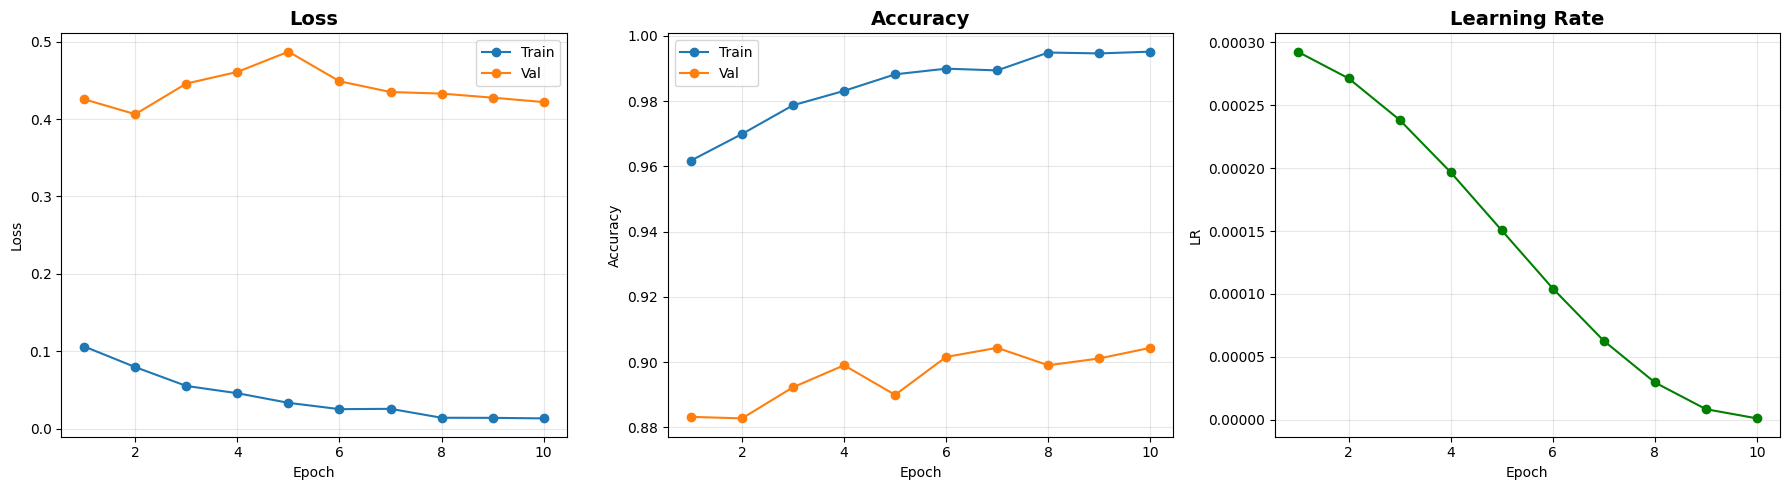

Plots saved to Drive.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'o-', label='Val')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'o-', label='Val')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# LR
axes[2].plot(epochs_range, history['lr'], 'o-', color='green')
axes[2].set_title('Learning Rate', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_plots.png', dpi=150)
plt.show()
print('Plots saved to Drive.')

## 7. Confidence Score Verification

In [17]:
# Load best weights
model.load_state_dict(best_state)
model.eval()

all_confs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels_t = torch.tensor(labels, dtype=torch.long, device=device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        confs, preds = probs.max(1)

        all_confs.extend(confs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_t.cpu().numpy())

all_confs  = np.array(all_confs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
correct_mask = all_preds == all_labels

print('=' * 55)
print('  CONFIDENCE SCORE REPORT')
print('=' * 55)
print(f'  Before fine-tuning:   50.0% (hardcoded heuristic)')
print(f'  After fine-tuning:    {all_confs.mean()*100:.1f}% (average)')
print(f'  Correct predictions:  {all_confs[correct_mask].mean()*100:.1f}%')
print(f'  Wrong predictions:    {all_confs[~correct_mask].mean()*100:.1f}%')
print(f'  Overall accuracy:     {correct_mask.mean()*100:.1f}%')
print(f'  Improvement:          +{(all_confs.mean()-0.50)*100:.1f}%')
print('=' * 55)

# Per-class accuracy
print('\nPer-Class Accuracy:')
print('-' * 35)
for i, cat in enumerate(CATEGORIES):
    mask = all_labels == i
    if mask.sum() > 0:
        acc = correct_mask[mask].mean() * 100
        conf = all_confs[mask].mean() * 100
        print(f'  {cat:12s}  Acc: {acc:5.1f}%  Conf: {conf:5.1f}%')
    else:
        print(f'  {cat:12s}  (no samples)')

/tmp/ipykernel_8032/3335557845.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_t = torch.tensor(labels, dtype=torch.long, device=device)


  CONFIDENCE SCORE REPORT
  Before fine-tuning:   50.0% (hardcoded heuristic)
  After fine-tuning:    96.3% (average)
  Correct predictions:  97.8%
  Wrong predictions:    82.0%
  Overall accuracy:     90.4%
  Improvement:          +46.3%

Per-Class Accuracy:
-----------------------------------
  shirt         Acc:  76.8%  Conf:  93.0%
  t-shirt       Acc:  86.0%  Conf:  93.5%
  jacket        Acc:  97.0%  Conf:  95.2%
  coat          Acc:  81.8%  Conf:  94.0%
  sweater       Acc:  87.8%  Conf:  95.3%
  hoodie        Acc:  99.0%  Conf:  94.4%
  jeans         Acc: 100.0%  Conf: 100.0%
  pants         Acc:  98.6%  Conf:  99.5%
  shorts        Acc: 100.0%  Conf: 100.0%
  dress         Acc:  88.4%  Conf:  95.2%
  skirt         Acc: 100.0%  Conf: 100.0%
  blouse        Acc: 100.0%  Conf: 100.0%
  suit          Acc: 100.0%  Conf: 100.0%
  tank_top      Acc: 100.0%  Conf: 100.0%
  other         Acc:  99.2%  Conf:  99.5%


## 8. Confidence Distribution Plot

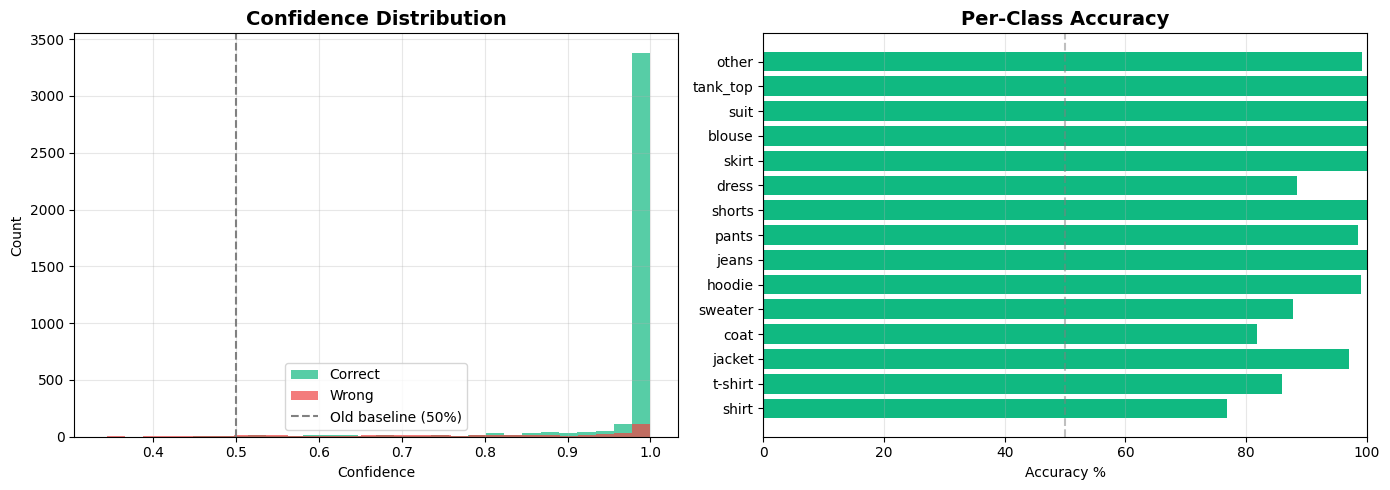

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(all_confs[correct_mask], bins=30, alpha=0.7, label='Correct', color='#10B981')
axes[0].hist(all_confs[~correct_mask], bins=30, alpha=0.7, label='Wrong', color='#EF4444')
axes[0].axvline(0.5, color='gray', linestyle='--', label='Old baseline (50%)')
axes[0].set_title('Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Per-class bar chart
cats_with_data = []
accs = []
for i, cat in enumerate(CATEGORIES):
    mask = all_labels == i
    if mask.sum() > 0:
        cats_with_data.append(cat)
        accs.append(correct_mask[mask].mean() * 100)

colors = ['#10B981' if a >= 70 else '#F59E0B' if a >= 50 else '#EF4444' for a in accs]
axes[1].barh(cats_with_data, accs, color=colors)
axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy %')
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, 100)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_report.png', dpi=150)
plt.show()

## 9. Export Weights

In [19]:
# Save to Drive
weights_path = f'{OUTPUT_DIR}/classifier.pth'
torch.save(best_state, weights_path)
size_mb = os.path.getsize(weights_path) / 1e6

print(f'Weights saved to: {weights_path}')
print(f'File size: {size_mb:.1f} MB')
print(f'Best val accuracy: {best_val_acc:.3f}')
print(f'\n--- NEXT STEPS ---')
print(f'1. Download classifier.pth from Google Drive > fashion_weights folder')
print(f'2. Place it at: models/weights/classifier.pth in your project')
print(f'3. Restart server: uvicorn app.main:app --reload --port 8001')

Weights saved to: /content/drive/MyDrive/fashion_weights/classifier.pth
File size: 16.4 MB
Best val accuracy: 0.904

--- NEXT STEPS ---
1. Download classifier.pth from Google Drive > fashion_weights folder
2. Place it at: models/weights/classifier.pth in your project
3. Restart server: uvicorn app.main:app --reload --port 8001


In [ ]:
# Quick download link (also available from Drive)
from google.colab import files
files.download(weights_path)

In [ ]:
import shutil

# Change this to wherever your augmented dataset is on Colab
SRC  = '/content/fashion_dataset_augmented'
DEST = '/content/drive/MyDrive/fashion_dataset_augmented'

shutil.copytree(SRC, DEST)
print(f'✅ Saved to: {DEST}')
